# Unit08_Example_01 | 化工案例一：化工物性數據之一維插值

本 Notebook 為 ChemE-3502「電腦在化工上之應用」課程 Unit08 的化工案例演練一。
以**水的動力黏度**隨溫度變化之稀疏實驗數據為例，
示範如何使用 `scipy.interpolate` 的各種一維插值方法，估算未測量溫度下的物性值。

## 學習目標
- 使用 `scipy.interpolate.interp1d()` 進行 nearest、linear、cubic 三種插值方法比較
- 使用 `scipy.interpolate.CubicSpline()` 進行三次樣條平滑插值
- 比較不同方法在物性數據上的精確度與平滑性差異
- 進行**逆向插值**：給定目標黏度值，反推對應溫度
- 以留存測試點驗證各插值方法的準確度

---
### 0. 環境設定

In [1]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit08_Example_01'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit08'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook工作目錄: d:\MyGit\ChemE-3502\Unit08
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_01
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit08\outputs\Unit08_Example_01\figs


---
### 1. 載入套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.interpolate import interp1d, CubicSpline
from scipy.optimize import brentq

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
    'axes.unicode_minus': False,
})

print("✓ 套件載入完成")
print(f"  numpy       版本: {np.__version__}")
import scipy
print(f"  scipy       版本: {scipy.__version__}")
import matplotlib
print(f"  matplotlib  版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy       版本: 1.23.5
  scipy       版本: 1.15.2
  matplotlib  版本: 3.10.8


---
### 2. 問題描述：水的動力黏度隨溫度變化之插值

#### 2.1 背景

液體的**動力黏度 (dynamic viscosity)** $\mu$ 是重要的化工物性，
常見於管流壓降計算、熱傳分析及質傳設計中。
黏度隨溫度升高而顯著降低，且通常以離散的實驗量測值呈現於教科書與工程手冊中。

#### 2.2 實驗數據（訓練數據點）

從文獻取得純水在不同溫度下的動力黏度量測值（Perry's Chemical Engineers' Handbook）：

| 溫度 $T$ (°C) | 0 | 10 | 20 | 40 | 60 | 80 | 100 |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 黏度 $\mu$ (mPa·s) | 1.792 | 1.307 | 1.002 | 0.653 | 0.467 | 0.355 | 0.282 |

#### 2.3 問題目標

1. 使用不同插值方法，估算**未測量溫度**（如 $T = 30, 50, 70$ °C）下的黏度值
2. 進行**逆向插值**：已知目標黏度 $\mu^* = 0.500$ mPa·s，反推對應溫度 $T^*$
3. 以留存的真實值（來自文獻）驗證各插值方法的精確度

#### 2.4 精確度驗證用數據（測試數據點）

| 溫度 $T$ (°C) | 30 | 50 | 70 |
|:---:|:---:|:---:|:---:|
| 文獻黏度 $\mu$ (mPa·s) | 0.798 | 0.547 | 0.404 |

In [3]:
# ============================================================
# 數據定義
# ============================================================

# 訓練數據點（已知量測值）
T_known = np.array([0, 10, 20, 40, 60, 80, 100], dtype=float)   # 溫度 (°C)
mu_known = np.array([1.792, 1.307, 1.002, 0.653, 0.467, 0.355, 0.282])  # 黏度 (mPa·s)

# 測試數據點（用於驗證，建立插值函數時不使用）
T_test = np.array([30.0, 50.0, 70.0])           # 溫度 (°C)
mu_test_true = np.array([0.798, 0.547, 0.404])  # 文獻黏度值 (mPa·s)

# 用於繪圖的細緻溫度軸
T_fine = np.linspace(0, 100, 500)

# 目標黏度（逆向插值用）
mu_target = 0.500  # mPa·s

# 顯示數據摘要
print("=" * 55)
print("  訓練數據點（已知量測值）")
print("=" * 55)
print(f"  {'T (°C)':>8}  {'μ (mPa·s)':>12}")
print("-" * 30)
for t, mu in zip(T_known, mu_known):
    print(f"  {t:>8.0f}  {mu:>12.4f}")
print()
print("=" * 55)
print("  測試數據點（精確度驗證用）")
print("=" * 55)
print(f"  {'T (°C)':>8}  {'μ_true (mPa·s)':>16}")
print("-" * 35)
for t, mu in zip(T_test, mu_test_true):
    print(f"  {t:>8.1f}  {mu:>16.4f}")
print()
print(f"  逆向插值目標: μ* = {mu_target} mPa·s")

  訓練數據點（已知量測值）
    T (°C)     μ (mPa·s)
------------------------------
         0        1.7920
        10        1.3070
        20        1.0020
        40        0.6530
        60        0.4670
        80        0.3550
       100        0.2820

  測試數據點（精確度驗證用）
    T (°C)    μ_true (mPa·s)
-----------------------------------
      30.0            0.7980
      50.0            0.5470
      70.0            0.4040

  逆向插值目標: μ* = 0.5 mPa·s


---
### 3. 建立插值函數：四種方法比較

使用 `scipy.interpolate.interp1d()` 建立三種插值方法，並以 `CubicSpline` 補充：

| 方法 | 函數呼叫 | 特性 |
|-----|---------|------|
| Nearest Neighbor | `interp1d(kind='nearest')` | 取最近數據點之值，結果為階梯函數 |
| Linear | `interp1d(kind='linear')` | 相鄰兩點間線性連接，簡單快速 |
| Cubic Spline | `interp1d(kind='cubic')` | C² 連續三次樣條插值（與 CubicSpline 類似） |
| CubicSpline | `CubicSpline(x, y)` | C² 連續三次樣條，not-a-knot 邊界條件，功能更完整 |

> **注意**：`interp1d` 預設 `bounds_error=True`，查詢值必須在數據範圍內。
> 若需外插，改用 `fill_value='extrapolate'`，但結果需謹慎評估。
> `interp1d(kind='cubic')` 與 `CubicSpline` 在相同數據下結果幾乎相同；
> 推薦使用 `CubicSpline`，功能更豐富（可求導、積分、設定邊界條件）。

In [4]:
# ============================================================
# 建立四種插值函數
# ============================================================

# (1) 最近鄰插值
f_nearest = interp1d(T_known, mu_known, kind='nearest')

# (2) 線性插值
f_linear = interp1d(T_known, mu_known, kind='linear')

# (3) 三次 Hermite 插值（保持單調性）
f_cubic = interp1d(T_known, mu_known, kind='cubic')

# (4) 三次樣條插值（CubicSpline，預設 not-a-knot 邊界條件）
f_cs = CubicSpline(T_known, mu_known)

# ============================================================
# 在測試溫度點評估插值結果
# ============================================================
T_query = np.array([30.0, 50.0, 70.0])

mu_nearest = f_nearest(T_query)
mu_linear  = f_linear(T_query)
mu_cubic   = f_cubic(T_query)
mu_cs      = f_cs(T_query)

# 顯示插值結果比較表
print("=" * 65)
print("  插值結果比較")
print("=" * 65)
print(f"  {'T (°C)':>7} {'Nearest':>10} {'Linear':>10} {'Cubic':>10} {'CubicSpline':>13}")
print("-" * 65)
for i, t in enumerate(T_query):
    print(f"  {t:>7.1f} {mu_nearest[i]:>10.4f} {mu_linear[i]:>10.4f} "
          f"{mu_cubic[i]:>10.4f} {mu_cs[i]:>13.4f}")
print()

# 對測試點計算誤差（以文獻值為基準）
print("=" * 65)
print("  與文獻值之絕對誤差 (mPa·s)")
print("=" * 65)
print(f"  {'T (°C)':>7} {'True μ':>8} {'Nearest':>10} {'Linear':>10} {'Cubic':>10} {'CubicSpline':>13}")
print("-" * 65)
for i, t in enumerate(T_query):
    mu_true = mu_test_true[i]
    print(f"  {t:>7.1f} {mu_true:>8.4f} "
          f"{abs(mu_nearest[i]-mu_true):>10.4f} "
          f"{abs(mu_linear[i]-mu_true):>10.4f} "
          f"{abs(mu_cubic[i]-mu_true):>10.4f} "
          f"{abs(mu_cs[i]-mu_true):>13.4f}")

  插值結果比較
   T (°C)    Nearest     Linear      Cubic   CubicSpline
-----------------------------------------------------------------
     30.0     1.0020     0.8275     0.7966        0.7966
     50.0     0.6530     0.5600     0.5472        0.5472
     70.0     0.4670     0.4110     0.4044        0.4044

  與文獻值之絕對誤差 (mPa·s)
   T (°C)   True μ    Nearest     Linear      Cubic   CubicSpline
-----------------------------------------------------------------
     30.0   0.7980     0.2040     0.0295     0.0014        0.0014
     50.0   0.5470     0.1060     0.0130     0.0002        0.0002
     70.0   0.4040     0.0630     0.0070     0.0004        0.0004


---
### 4. 插值曲線比較圖

以連續曲線呈現四種插值方法在 $T = 0 \sim 100$ °C 範圍的插值結果，
並標示已知數據點（訓練點）與測試數據點。

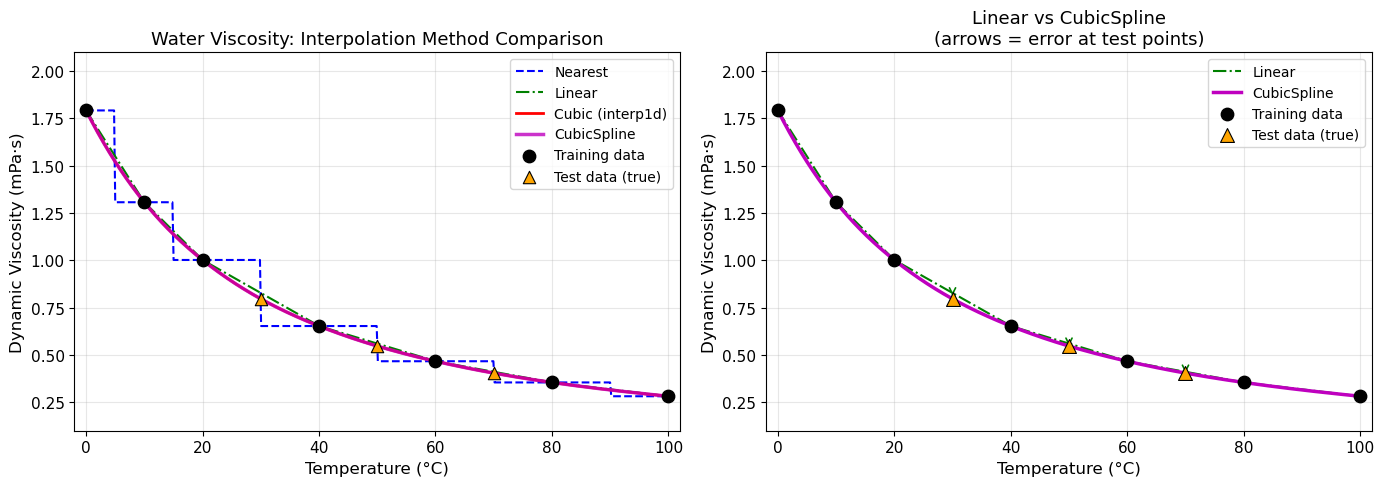


✓ 圖片已儲存


In [9]:
# ============================================================
# 繪製插值曲線比較圖
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------- 左圖：四種方法完整比較 ----------
ax1 = axes[0]

ax1.plot(T_fine, f_nearest(T_fine), 'b--',  lw=1.5, label='Nearest')
ax1.plot(T_fine, f_linear(T_fine),  'g-.',  lw=1.5, label='Linear')
ax1.plot(T_fine, f_cubic(T_fine),   'r-',   lw=2.0, label='Cubic (interp1d)')
ax1.plot(T_fine, f_cs(T_fine),      'm-',   lw=2.5, label='CubicSpline', alpha=0.8)
ax1.scatter(T_known, mu_known, s=80, c='k', zorder=5, label='Training data')
ax1.scatter(T_test, mu_test_true, s=80, marker='^', c='orange',
            zorder=5, edgecolors='k', linewidths=0.8, label='Test data (true)')

ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Dynamic Viscosity (mPa·s)')
ax1.set_title('Water Viscosity: Interpolation Method Comparison')
ax1.legend(loc='upper right')
ax1.set_xlim(-2, 102)
ax1.set_ylim(0.1, 2.1)

# ---------- 右圖：Linear vs CubicSpline ----------
ax2 = axes[1]

ax2.plot(T_fine, f_linear(T_fine),  'g-.', lw=1.5, label='Linear')
ax2.plot(T_fine, f_cs(T_fine),      'm-',  lw=2.5, label='CubicSpline')
ax2.scatter(T_known, mu_known, s=80, c='k', zorder=5, label='Training data')
ax2.scatter(T_test, mu_test_true, s=100, marker='^', c='orange',
            zorder=5, edgecolors='k', linewidths=0.8, label='Test data (true)')

# 標示誤差箭頭（T=30 處）
for t, mu_true, mu_lin, mu_cs_val in zip(T_query, mu_test_true, mu_linear, mu_cs):
    ax2.annotate('', xy=(t, mu_lin), xytext=(t, mu_true),
                 arrowprops=dict(arrowstyle='<->', color='green', lw=1.2))

ax2.set_xlabel('Temperature (°C)')
ax2.set_ylabel('Dynamic Viscosity (mPa·s)')
ax2.set_title('Linear vs CubicSpline\n(arrows = error at test points)')
ax2.legend(loc='upper right')
ax2.set_xlim(-2, 102)
ax2.set_ylim(0.1, 2.1)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig1_interpolation_comparison.png', bbox_inches='tight')
plt.show()
print("\n✓ 圖片已儲存")

---
### 5. 逆向插值：由目標黏度反推對應溫度

**問題**：如果製程需要黏度恰好為 $\mu^* = 0.500$ mPa·s 的水溶液，
應將溫度控制在多少攝氏度？

**方法**：定義方程式 $g(T) = f_{CS}(T) - \mu^*$，
使用 `scipy.optimize.brentq` 在已知黏度單調遞減的範圍內求解 $g(T) = 0$。

$$T^* = f_{CS}^{-1}(\mu^*) \quad \text{即求解} \quad f_{CS}(T^*) = \mu^*$$

逆向插值結果:
  目標黏度 μ* = 0.5000 mPa·s
  對應溫度 T* = 55.56 °C
  驗證: f_cs(55.56) = 0.500000 mPa·s



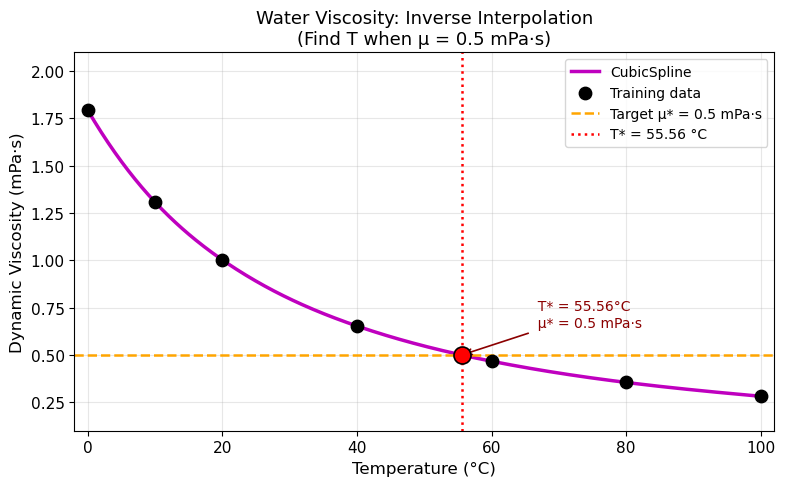

✓ 圖片已儲存


In [6]:
# ============================================================
# 逆向插值：給定目標黏度，反推溫度
# ============================================================

def g_inverse(T):
    """方程式: f_cs(T) - mu_target = 0"""
    return f_cs(T) - mu_target

# 使用 brentq 在 [T_known.min, T_known.max] 範圍內求解
T_star = brentq(g_inverse, T_known.min(), T_known.max())
mu_verify = f_cs(T_star)

print(f"逆向插值結果:")
print(f"  目標黏度 μ* = {mu_target:.4f} mPa·s")
print(f"  對應溫度 T* = {T_star:.2f} °C")
print(f"  驗證: f_cs({T_star:.2f}) = {mu_verify:.6f} mPa·s")
print()

# ============================================================
# 逆向插值示意圖
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(T_fine, f_cs(T_fine), 'm-', lw=2.5, label='CubicSpline')
ax.scatter(T_known, mu_known, s=80, c='k', zorder=5, label='Training data')

# 標示目標黏度水平線與對應溫度
ax.axhline(mu_target, color='orange', ls='--', lw=1.8,
           label=f'Target μ* = {mu_target} mPa·s')
ax.axvline(T_star, color='red', ls=':', lw=1.8,
           label=f'T* = {T_star:.2f} °C')
ax.scatter([T_star], [mu_target], s=150, c='red', zorder=6,
           edgecolors='k', linewidths=1.2)

ax.annotate(f'  T* = {T_star:.2f}°C\n  μ* = {mu_target} mPa·s',
            xy=(T_star, mu_target), xytext=(T_star + 10, mu_target + 0.15),
            fontsize=10, color='darkred',
            arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2))

ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Dynamic Viscosity (mPa·s)')
ax.set_title('Water Viscosity: Inverse Interpolation\n'
             f'(Find T when μ = {mu_target} mPa·s)')
ax.legend(loc='upper right')
ax.set_xlim(-2, 102)
ax.set_ylim(0.1, 2.1)

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig2_inverse_interpolation.png', bbox_inches='tight')
plt.show()
print("✓ 圖片已儲存")

---
### 6. 精確度驗證：留存測試點比較

以三個預先留存的文獻量測值（$T = 30, 50, 70$ °C）評估各插值方法的精確度。

定義**相對誤差**（百分比）為：

$$\text{相對誤差} = \frac{|\mu_{\text{interp}} - \mu_{\text{true}}|}{\mu_{\text{true}}} \times 100\%$$

> **物理解釋**：液體黏度隨溫度升高而降低，且降低幅度非線性，
> 因此在數據點稀疏（如本例 $T = 20 \to 40$ °C 跨越 20°C）的區間，
> 線性插值誤差較大，而 CubicSpline 能更準確捕捉非線性特性。

  精確度驗證結果（與文獻值比較）
  T (°C)   True μ       Nearest        Linear         Cubic   CubicSpline
                           Err%          Err%          Err%          Err%
---------------------------------------------------------------------------
    30.0   0.7980        25.56%         3.70%         0.18%         0.18%
    50.0   0.5470        19.38%         2.38%         0.03%         0.03%
    70.0   0.4040        15.59%         1.73%         0.10%         0.10%

  平均絕對相對誤差 (MARE):
         Nearest: 20.18%
          Linear: 2.60%
           Cubic: 0.10%
     CubicSpline: 0.10%


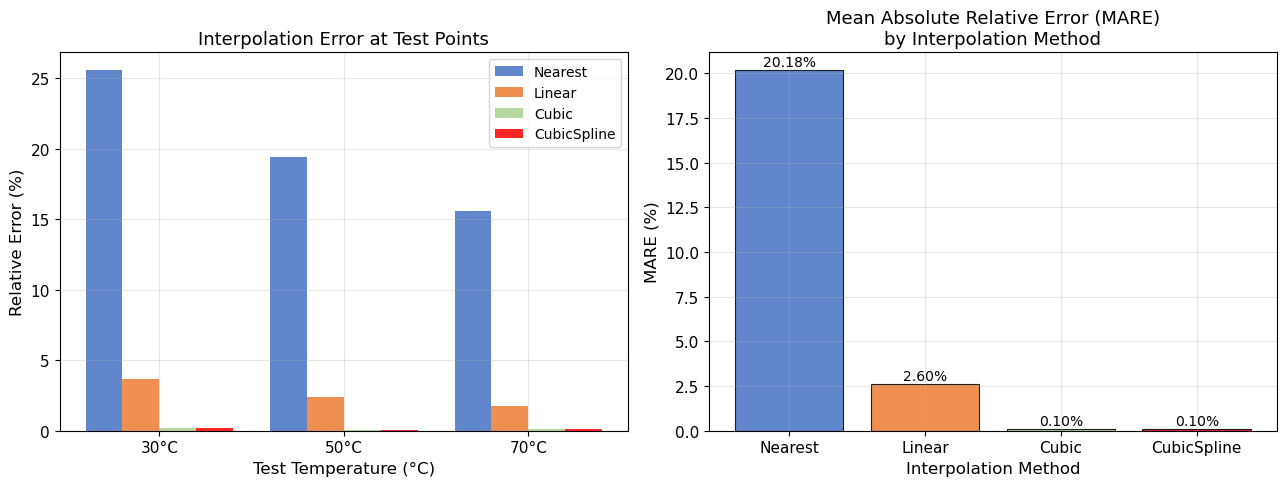


✓ 圖片已儲存

✅  Unit08_Example_01 全部完成！


In [7]:
# ============================================================
# 精確度驗證：相對誤差計算與比較圖
# ============================================================

methods = {
    'Nearest':     f_nearest(T_test),
    'Linear':      f_linear(T_test),
    'Cubic':       f_cubic(T_test),
    'CubicSpline': f_cs(T_test),
}

# 計算絕對誤差與相對誤差
print("=" * 75)
print("  精確度驗證結果（與文獻值比較）")
print("=" * 75)
print(f"  {'T (°C)':>6} {'True μ':>8}", end="")
for name in methods:
    print(f"  {name:>12}", end="")
print()
print(f"  {'':>6} {'':>8}", end="")
for name in methods:
    print(f"  {'Err%':>12}", end="")
print()
print("-" * 75)

for i, (t, mu_true) in enumerate(zip(T_test, mu_test_true)):
    print(f"  {t:>6.1f} {mu_true:>8.4f}", end="")
    for name, vals in methods.items():
        rel_err = abs(vals[i] - mu_true) / mu_true * 100
        print(f"  {rel_err:>11.2f}%", end="")
    print()

print()
# 每種方法的平均絕對相對誤差 (MARE)
print("  平均絕對相對誤差 (MARE):")
for name, vals in methods.items():
    mare = np.mean(np.abs(vals - mu_test_true) / mu_test_true * 100)
    print(f"    {name:>12}: {mare:.2f}%")

# ============================================================
# 誤差比較長條圖
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#4472C4', '#ED7D31', '#A9D18E', '#FF0000']
x = np.arange(len(T_test))
width = 0.2

# --- 左圖：各溫度點的相對誤差 ---
ax1 = axes[0]
for k, (name, vals) in enumerate(methods.items()):
    rel_errs = np.abs(vals - mu_test_true) / mu_test_true * 100
    ax1.bar(x + k * width, rel_errs, width, label=name, color=colors[k], alpha=0.85)

ax1.set_xlabel('Test Temperature (°C)')
ax1.set_ylabel('Relative Error (%)')
ax1.set_title('Interpolation Error at Test Points')
ax1.set_xticks(x + 1.5 * width)
ax1.set_xticklabels([f'{int(t)}°C' for t in T_test])
ax1.legend()

# --- 右圖：MARE 長條圖 ---
ax2 = axes[1]
names = list(methods.keys())
mare_vals = [np.mean(np.abs(v - mu_test_true) / mu_test_true * 100)
             for v in methods.values()]
bars = ax2.bar(names, mare_vals, color=colors, alpha=0.85, edgecolor='k', linewidth=0.8)
for bar, val in zip(bars, mare_vals):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=10)

ax2.set_xlabel('Interpolation Method')
ax2.set_ylabel('MARE (%)')
ax2.set_title('Mean Absolute Relative Error (MARE)\nby Interpolation Method')

plt.tight_layout()
fig.savefig(FIG_DIR / 'fig3_accuracy_comparison.png', bbox_inches='tight')
plt.show()

print("\n✓ 圖片已儲存")
print("\n✅  Unit08_Example_01 全部完成！")